# Ridge Regression Backtest

Ce notebook implémente un backtest **walk-forward** d'un modèle Ridge qui combine
toutes les features pour prédire le rendement futur de chaque asset.

**Objectif pédagogique :** maîtriser la manipulation de données panel (MultiIndex),
la normalisation cross-sectionelle, et le walk-forward en pandas.

---

### Pipeline
```
1. Construire le panel MultiIndex (date × asset)
2. Calculer toutes les features → matrice X
3. Normaliser X cross-sectionnellement à chaque date
4. Définir la cible y = rendement t+1
5. Walk-forward : entraîner Ridge sur passé, prédire futur
6. Backtest : convertir prédictions en positions → P&L
7. Évaluer : Sharpe, drawdown, feature importance
```

In [1]:
import pathlib, sys, importlib
ROOT = pathlib.Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yaml
import warnings
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ── Paramètres ────────────────────────────────────────────────────────────────
RAW      = ROOT / 'data' / 'raw'
EXCHANGE = 'binance-futures'
ASSETS   = [
    'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'LTCUSDT', 'BNBUSDT',
    'XRPUSDT', 'ADAUSDT', 'DOTUSDT', 'LINKUSDT', 'AVAXUSDT',
    'ATOMUSDT', 'UNIUSDT', 'XLMUSDT', 'TRXUSDT', 'ETCUSDT',
]

# Features à utiliser dans le Ridge
FEATURE_IDS = [
    'ret_1d', 'mom_20d', 'rv_30d', 'cvd_20d',
    'reversal_5d', 'dist_from_high_20d', 'vol_ratio_20d',
    'taker_ratio_20d', 'rel_mom_20d', 'risk_adj_ret_20d',
    'hl_range_20d', 'trades_zscore_20d', 'zscore_ret_composite',
]

# Walk-forward : fenêtres d'entraînement et de test
TRAIN_START = '2020-01-01'
FOLDS = [
    {'train_end': '2022-12-31', 'test_start': '2023-01-01', 'test_end': '2023-12-31'},
    {'train_end': '2023-12-31', 'test_start': '2024-01-01', 'test_end': '2024-12-31'},
    {'train_end': '2024-12-31', 'test_start': '2025-01-01', 'test_end': '2025-12-31'},
]

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True,
    'grid.alpha': 0.3, 'axes.spines.top': False, 'axes.spines.right': False,
})
print(f'{len(ASSETS)} assets  |  {len(FEATURE_IDS)} features  |  {len(FOLDS)} folds')

15 assets  |  13 features  |  3 folds


## 1. Chargement des données OHLCV

On charge chaque asset et on les empile dans un **DataFrame MultiIndex** `(date, asset)`.
C'est la structure standard pour les données panel en quant finance.

In [2]:
def load_ohlcv(symbol: str) -> pd.DataFrame:
    """Charge les OHLCV daily depuis le hive store local."""
    base  = RAW / f'exchange={EXCHANGE}' / 'data_type=ohlcv_1d' / f'symbol={symbol}'
    parts = sorted(base.rglob('part-*.parquet'))
    if not parts:
        return pd.DataFrame()
    df = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
    df['date'] = pd.to_datetime(df['ts_open'], unit='us', utc=True).dt.normalize()
    return df.sort_values('date').drop_duplicates('date').set_index('date')

# ── Charger tous les assets et concaténer en MultiIndex ──────────────────────
# pd.concat avec keys crée automatiquement un MultiIndex (asset, date)
raw_frames = {}
for sym in ASSETS:
    df = load_ohlcv(sym)
    if not df.empty:
        raw_frames[sym] = df

# Empilement : MultiIndex (asset, date)
raw_panel = pd.concat(raw_frames, names=['asset', 'date'])

print('Panel MultiIndex (asset, date) :')
print(f'  Shape    : {raw_panel.shape}')
print(f'  Assets   : {raw_panel.index.get_level_values("asset").unique().tolist()}')
print(f'  Dates    : {raw_panel.index.get_level_values("date").min().date()} → '
      f'{raw_panel.index.get_level_values("date").max().date()}')
print()
print(raw_panel[['close', 'volume']].head(8))

Panel MultiIndex (asset, date) :
  Shape    : (33848, 12)
  Assets   : ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'LTCUSDT', 'BNBUSDT', 'XRPUSDT', 'ADAUSDT', 'DOTUSDT', 'LINKUSDT', 'AVAXUSDT', 'ATOMUSDT', 'UNIUSDT', 'XLMUSDT', 'TRXUSDT', 'ETCUSDT']
  Dates    : 2020-01-01 → 2026-06-01

                                     close      volume
asset   date                                          
BTCUSDT 2020-01-01 00:00:00+00:00  7197.57   56801.329
        2020-01-02 00:00:00+00:00  6962.04  115295.677
        2020-01-03 00:00:00+00:00  7341.72  208493.458
        2020-01-04 00:00:00+00:00  7350.71   92586.033
        2020-01-05 00:00:00+00:00  7354.36  117765.972
        2020-01-06 00:00:00+00:00  7757.39  168150.317
        2020-01-07 00:00:00+00:00  8152.49  280809.162
        2020-01-08 00:00:00+00:00  8059.84  321225.114


## 2. Construction de la matrice de features X

Pour chaque feature, on appelle `compute(df, params)` sur chaque asset
et on assemble le résultat dans un DataFrame panel `(date, asset) × features`.

**Technique pandas :** `pd.concat` avec `axis=1` pour empiler les colonnes.

In [3]:
# ── Chargement du registre features.yaml ─────────────────────────────────────
with open(ROOT / 'configs' / 'features.yaml') as f:
    registry = {feat['id']: feat for feat in yaml.safe_load(f)['features']}

# ── Calcul de chaque feature sur chaque asset ─────────────────────────────────
feature_series = {}   # {feature_id: pd.Series avec MultiIndex (date, asset)}

for fid in FEATURE_IDS:
    cfg    = registry[fid]
    params = cfg.get('params', {})
    mod    = importlib.import_module(f'dfi_features.{fid}')

    # Calcul par asset, puis empilement
    parts = []
    for sym, df in raw_frames.items():
        s = mod.compute(df, params)
        if not s.empty:
            # On crée un MultiIndex (date, asset) sur la série
            s.index = pd.MultiIndex.from_arrays(
                [s.index, [sym] * len(s)],
                names=['date', 'asset']
            )
            parts.append(s)

    if parts:
        feature_series[fid] = pd.concat(parts)

# ── Assembler toutes les features en un DataFrame ─────────────────────────────
# pd.DataFrame(dict) avec des Series MultiIndex → DataFrame (date, asset) × features
X_raw = pd.DataFrame(feature_series)
X_raw.index.names = ['date', 'asset']

print('Matrice de features X (avant normalisation) :')
print(f'  Shape : {X_raw.shape}  →  {X_raw.shape[0]} observations × {X_raw.shape[1]} features')
print(f'  NaN   : {X_raw.isna().mean().round(3).to_dict()}')
print()
print(X_raw.head(8).round(4))

Matrice de features X (avant normalisation) :
  Shape : (33848, 13)  →  33848 observations × 13 features
  NaN   : {'ret_1d': 0.0, 'mom_20d': 0.009, 'rv_30d': 0.013, 'cvd_20d': 0.008, 'reversal_5d': 0.002, 'dist_from_high_20d': 0.008, 'vol_ratio_20d': 0.12, 'taker_ratio_20d': 0.008, 'rel_mom_20d': 0.12, 'risk_adj_ret_20d': 0.12, 'hl_range_20d': 0.12, 'trades_zscore_20d': 0.008, 'zscore_ret_composite': 0.133}

                                   ret_1d  mom_20d  rv_30d  cvd_20d  \
date                      asset                                       
2020-01-01 00:00:00+00:00 BTCUSDT     NaN      NaN     NaN      NaN   
2020-01-02 00:00:00+00:00 BTCUSDT -0.0333      NaN     NaN      NaN   
2020-01-03 00:00:00+00:00 BTCUSDT  0.0531      NaN     NaN      NaN   
2020-01-04 00:00:00+00:00 BTCUSDT  0.0012      NaN     NaN      NaN   
2020-01-05 00:00:00+00:00 BTCUSDT  0.0005      NaN     NaN      NaN   
2020-01-06 00:00:00+00:00 BTCUSDT  0.0534      NaN     NaN      NaN   
2020-01-07 00:00:00

## 3. Cible y — rendement forward à 1 jour

`y(t) = close(t+1) / close(t) - 1`

**Technique pandas :** `groupby` + `shift` pour calculer le rendement futur
par asset sans faire fuiter les données d'un asset à l'autre.

In [4]:
# ── Rendement futur par asset ─────────────────────────────────────────────────
# groupby('asset') garantit que le shift(-1) ne traverse pas les frontières d'assets
close_panel = raw_panel['close'].astype(float)
ret_1d = close_panel.groupby(level='asset').pct_change()    # ret simple

# shift(-1) dans chaque groupe asset = rendement du lendemain
y = ret_1d.groupby(level='asset').shift(-1).rename('ret_fwd')

# Réordonner l'index pour matcher X_raw (date, asset)
# X_raw a (date, asset), y a (asset, date) → on réindexe
y = y.reorder_levels(['date', 'asset']).sort_index()

print('Cible y :')
print(f'  Shape  : {y.shape}')
print(f'  Moyenne: {y.mean():.5f}  |  Std: {y.std():.5f}')
print()
# Aperçu : rendements futurs BTCUSDT
print(y.xs('BTCUSDT', level='asset').tail(5))

Cible y :
  Shape  : (33848,)
  Moyenne: 0.00188  |  Std: 0.05192

date
2026-05-06 00:00:00+00:00   -0.017455
2026-05-07 00:00:00+00:00    0.002323
2026-05-08 00:00:00+00:00    0.005973
2026-05-09 00:00:00+00:00    0.019145
2026-05-10 00:00:00+00:00         NaN
Name: ret_fwd, dtype: float64


## 4. Normalisation cross-sectionnelle

À chaque date `t`, on **standardise les features à travers les assets** :
```
X_norm(t, asset_i) = (X(t, asset_i) - mean_t(X)) / std_t(X)
```

Pourquoi ? Une feature comme `rv_30d` a des valeurs très différentes de `reversal_5d`.
La normalisation cross-sectionnelle les rend comparables ET élimine le beta de marché commun.

**Technique pandas :** `groupby(level='date').transform` applique une fonction
à chaque groupe de dates — exactement ce qu'on veut.

In [5]:
def cross_section_normalize(df: pd.DataFrame) -> pd.DataFrame:
    """Z-score cross-sectionnel : soustrait la moyenne cross-asset et divise par l'écart-type.
    
    groupby(level='date') groupe les lignes par date.
    transform() applique la fonction à chaque groupe et retourne le même index.
    """
    mean = df.groupby(level='date').transform('mean')
    std  = df.groupby(level='date').transform('std').replace(0, np.nan)
    return (df - mean) / std

X_norm = cross_section_normalize(X_raw)

print('Matrice X normalisée cross-sectionnellement :')
print(f'  Moyenne globale : {X_norm.mean().mean():.6f}  (≈ 0 ✅)')
print(f'  NaN rate        : {X_norm.isna().mean().mean():.3f}')
print()
# Vérification : à chaque date, la moyenne cross-asset doit être 0
daily_means = X_norm.groupby(level='date')['reversal_5d'].mean()
print(f'  Moyenne daily reversal_5d (doit être ≈ 0 partout) :')
print(f'  min={daily_means.min():.6f}  max={daily_means.max():.6f}  mean={daily_means.mean():.6f}')

Matrice X normalisée cross-sectionnellement :
  Moyenne globale : -0.000000  (≈ 0 ✅)
  NaN rate        : 0.052

  Moyenne daily reversal_5d (doit être ≈ 0 partout) :
  min=-0.000000  max=0.000000  mean=-0.000000


## 5. Alignement X et y

On aligne la matrice de features et la cible sur le même index,
puis on supprime les lignes avec des NaN.

**Technique pandas :** `pd.concat(..., axis=1).dropna()` — la façon la plus
propre d'aligner deux DataFrames sur un MultiIndex commun.

In [6]:
# ── Alignement X et y sur le même MultiIndex ──────────────────────────────────
dataset = pd.concat([X_norm, y], axis=1).dropna().sort_index()

# Séparer features et cible
X = dataset[FEATURE_IDS]
y_aligned = dataset['ret_fwd']

print('Dataset final aligné :')
print(f'  Shape X : {X.shape}')
print(f'  Shape y : {y_aligned.shape}')
print(f'  Index   : (date, asset) — {X.index.get_level_values("date").min().date()} '
      f'→ {X.index.get_level_values("date").max().date()}')
print(f'  NaN     : {X.isna().sum().sum()}  (doit être 0 ✅)')
print()

# Aperçu
print('5 premières lignes de X :')
print(X.head().round(3))

Dataset final aligné :
  Shape X : (29243, 13)
  Shape y : (29243,)
  Index   : (date, asset) — 2020-10-27 → 2026-05-31
  NaN     : 0  (doit être 0 ✅)

5 premières lignes de X :
                                   ret_1d  mom_20d  rv_30d  cvd_20d  \
date                      asset                                       
2020-10-27 00:00:00+00:00 BTCUSDT   2.052    1.040  -1.064    1.342   
                          ETHUSDT   0.985    0.487  -0.638    0.365   
2020-10-28 00:00:00+00:00 BTCUSDT   0.608    1.082  -1.073    1.366   
                          ETHUSDT   0.193    0.513  -0.621    0.250   
2020-10-29 00:00:00+00:00 BTCUSDT   1.359    1.279  -1.076    1.561   

                                   reversal_5d  dist_from_high_20d  \
date                      asset                                      
2020-10-27 00:00:00+00:00 BTCUSDT       -1.172               0.749   
                          ETHUSDT        0.137               0.467   
2020-10-28 00:00:00+00:00 BTCUSDT       -1.2

## 6. Walk-forward Ridge

Le walk-forward reproduit ce qui se passerait en production :
- On entraîne uniquement sur le **passé**
- On prédit sur le **futur** (jamais vu)
- On avance la fenêtre et on répète

**`RidgeCV`** : Ridge avec sélection automatique du paramètre de régularisation α
par validation croisée sur la fenêtre d'entraînement.

```
Fold 1 : train 2020-2022 → test 2023
Fold 2 : train 2020-2023 → test 2024
Fold 3 : train 2020-2024 → test 2025
```

In [7]:
def slice_panel(X: pd.DataFrame, y: pd.Series,
                start: str, end: str) -> tuple:
    """Sélectionne les observations entre deux dates dans un MultiIndex (date, asset).
    
    pd.IndexSlice permet de slicer sur un niveau spécifique d'un MultiIndex.
    """
    idx = pd.IndexSlice[start:end, :]
    return X.loc[idx], y.loc[idx]

# ── Walk-forward ──────────────────────────────────────────────────────────────
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]   # valeurs de régularisation testées

fold_results = []
coef_history = []

for fold in FOLDS:
    train_end   = fold['train_end']
    test_start  = fold['test_start']
    test_end    = fold['test_end']

    # ── Données d'entraînement ────────────────────────────────────────────────
    X_train, y_train = slice_panel(X, y_aligned, TRAIN_START, train_end)
    X_test,  y_test  = slice_panel(X, y_aligned, test_start,  test_end)

    print(f'Fold {test_start[:4]} | train={len(X_train):,} obs | test={len(X_test):,} obs')

    # ── Entraînement Ridge ────────────────────────────────────────────────────
    # RidgeCV choisit le meilleur alpha par validation croisée
    model = RidgeCV(alphas=alphas, fit_intercept=False)
    model.fit(X_train, y_train)
    print(f'  Alpha optimal : {model.alpha_:.3f}')

    # ── Prédictions sur le test ───────────────────────────────────────────────
    y_pred = pd.Series(model.predict(X_test), index=X_test.index, name='prediction')

    # ── IC out-of-sample ──────────────────────────────────────────────────────
    # IC = corrélation de rang entre prédiction et vrai rendement
    ic = y_pred.corr(y_test, method='spearman')
    print(f'  IC out-of-sample : {ic:+.4f}')

    # Stocker les coefficients (feature importance)
    coef_history.append(pd.Series(model.coef_, index=FEATURE_IDS, name=test_start[:4]))

    fold_results.append({
        'fold':       test_start[:4],
        'y_pred':     y_pred,
        'y_true':     y_test,
        'alpha':      model.alpha_,
        'ic':         ic,
    })
    print()

coef_df = pd.DataFrame(coef_history)
print('Coefficients Ridge par fold :')
print(coef_df.round(4).to_string())

Fold 2023 | train=10,723 obs | test=5,430 obs
  Alpha optimal : 1000.000
  IC out-of-sample : -0.0165

Fold 2024 | train=16,153 obs | test=5,490 obs
  Alpha optimal : 1000.000
  IC out-of-sample : -0.0085

Fold 2025 | train=21,643 obs | test=5,445 obs
  Alpha optimal : 1000.000
  IC out-of-sample : +0.0035

Coefficients Ridge par fold :
      ret_1d  mom_20d  rv_30d  cvd_20d  reversal_5d  dist_from_high_20d  vol_ratio_20d  taker_ratio_20d  rel_mom_20d  risk_adj_ret_20d  hl_range_20d  trades_zscore_20d  zscore_ret_composite
2023  0.0005  -0.0001 -0.0009  -0.0004      -0.0008             -0.0002         0.0004           0.0002       0.0006            0.0011        0.0007            -0.0008                0.0001
2024  0.0003   0.0001 -0.0004  -0.0003      -0.0006              0.0000         0.0002           0.0002       0.0006            0.0003        0.0006            -0.0007                0.0001
2025 -0.0002  -0.0001 -0.0004  -0.0002      -0.0003              0.0002         0.0000     

## 7. Backtest sur les prédictions

On convertit les prédictions Ridge en positions **cross-sectionnelles démédanées**.

Les prédictions sont déjà cross-sectionnellement normalisées (X était normalisé),
donc elles forment naturellement un signal long/short.

**Technique pandas :** `groupby(level='date').transform` pour normaliser
les poids à chaque date.

In [8]:
# ── Concaténer les prédictions de tous les folds ──────────────────────────────
all_preds = pd.concat([r['y_pred'] for r in fold_results])
all_true  = pd.concat([r['y_true'] for r in fold_results])

# ── Poids proportionnels cross-sectionnel ────────────────────────────────────
# w_i(t) = pred_i(t) / Σ|pred_j(t)|  — dollar-neutral par construction
abs_sum = all_preds.groupby(level='date').transform(lambda x: x.abs().sum())
weights = all_preds / abs_sum.replace(0, np.nan)

# ── Rendement du portefeuille ─────────────────────────────────────────────────
# strat_ret(t) = Σ_i w_i(t) × ret_fwd_i(t)
strat_ret = (weights * all_true).groupby(level='date').sum()
port_value = (1 + strat_ret.fillna(0)).cumprod()

# ── Métriques ─────────────────────────────────────────────────────────────────
def sharpe(r, freq=252):
    r = r.dropna()
    return (r.mean() / r.std()) * np.sqrt(freq) if r.std() > 0 else float('nan')

def max_dd(pv):
    return ((pv - pv.cummax()) / pv.cummax()).min()

ic_global = all_preds.corr(all_true, method='spearman')
sh        = sharpe(strat_ret)
dd        = max_dd(port_value)
wr        = (strat_ret > 0).mean()

print('=' * 55)
print('  RÉSULTATS OUT-OF-SAMPLE (walk-forward)')
print('=' * 55)
print(f'  Période     : {strat_ret.index.min().date()} → {strat_ret.index.max().date()}')
print(f'  IC global   : {ic_global:+.4f}')
print(f'  Sharpe      : {sh:+.3f}')
print(f'  Max DD      : {dd*100:.1f}%')
print(f'  Win rate    : {wr*100:.1f}%')
print(f'  Return total: {(port_value.iloc[-1]-1)*100:.1f}%')
print('=' * 55)

print('\nIC par fold :')
for r in fold_results:
    print(f"  {r['fold']} : IC = {r['ic']:+.4f}")

  RÉSULTATS OUT-OF-SAMPLE (walk-forward)
  Période     : 2023-01-01 → 2025-12-31
  IC global   : -0.0083
  Sharpe      : +0.485
  Max DD      : -21.4%
  Win rate    : 50.8%
  Return total: 38.2%

IC par fold :
  2023 : IC = -0.0165
  2024 : IC = -0.0085
  2025 : IC = +0.0035


## 8. Visualisations

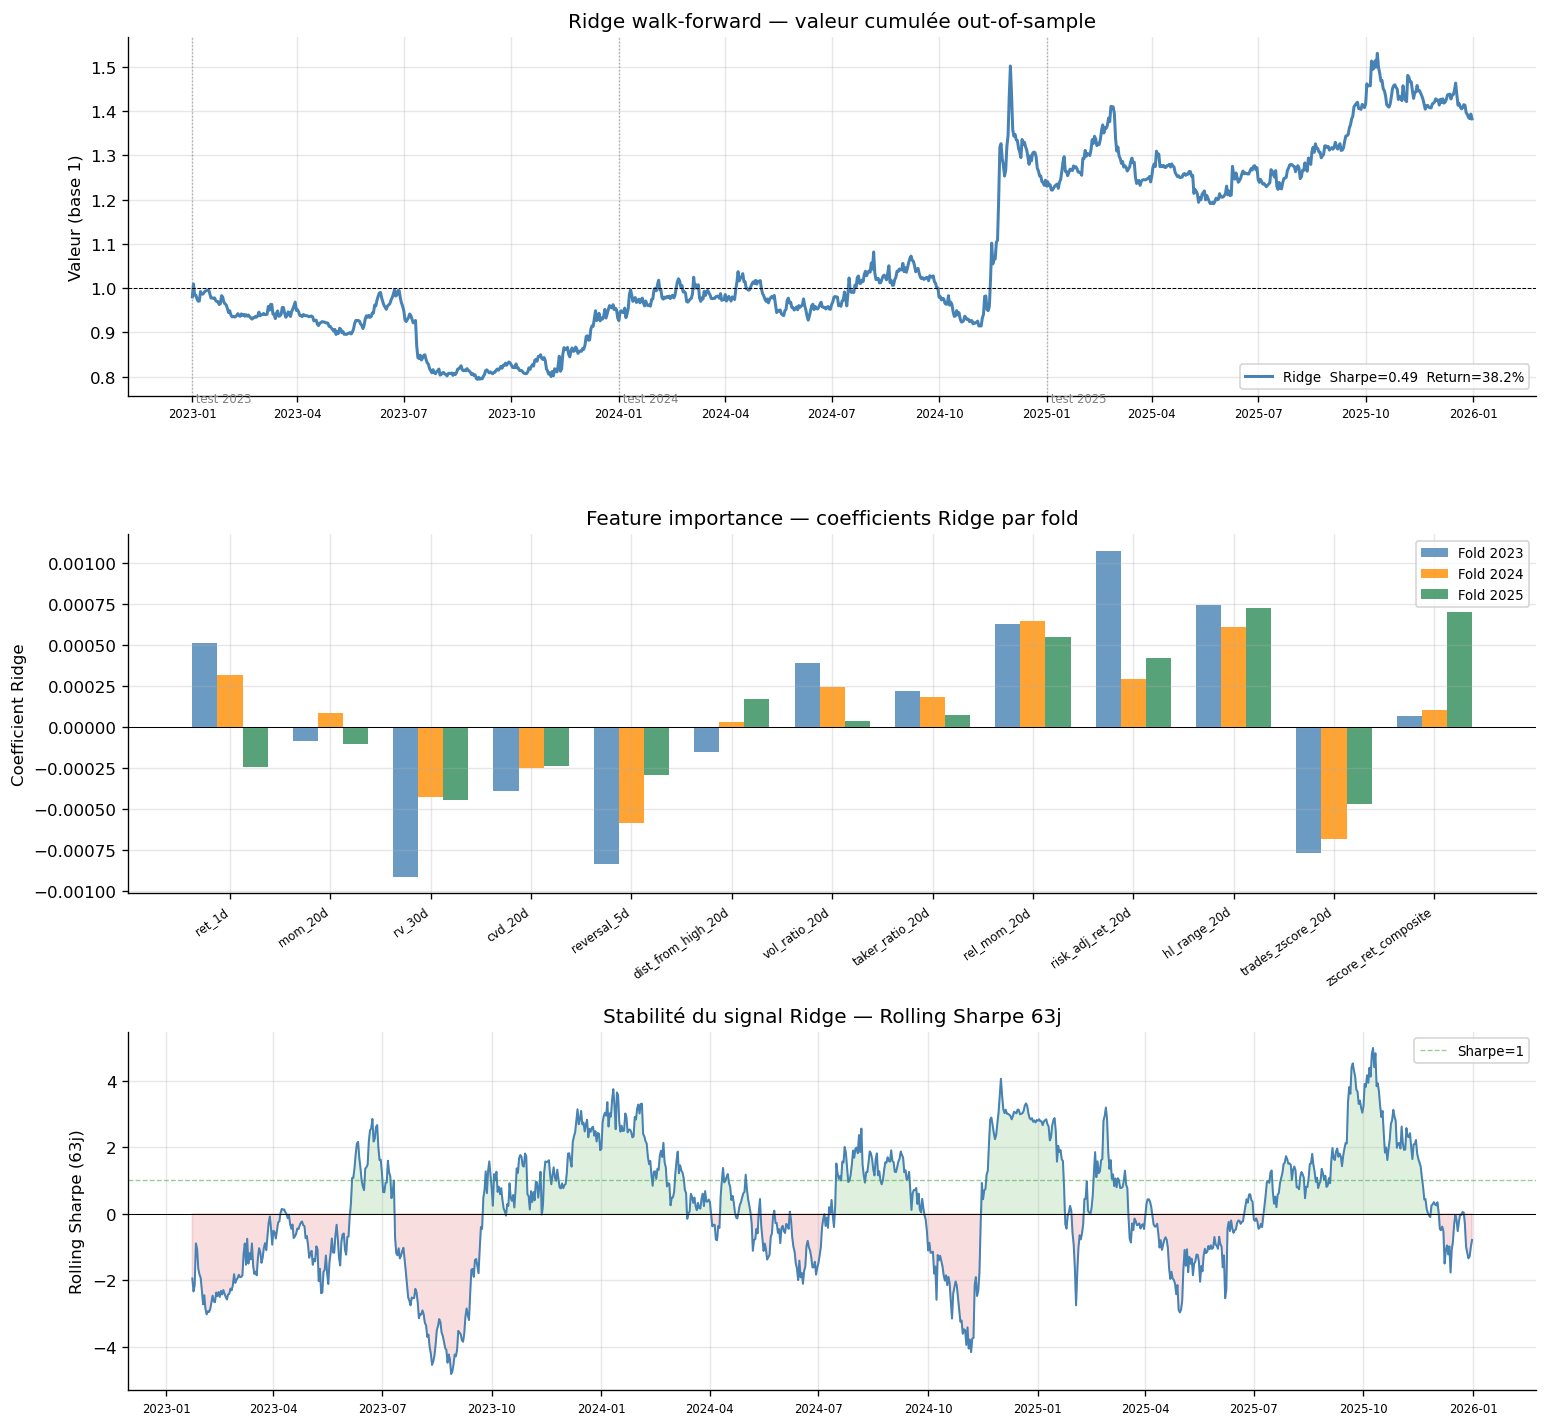

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=False)

# ── Panel 1 : valeur cumulée ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(port_value.index, port_value.values, lw=1.8, color='steelblue',
        label=f'Ridge  Sharpe={sh:.2f}  Return={(port_value.iloc[-1]-1)*100:.1f}%')
ax.axhline(1, color='k', lw=0.6, ls='--')

# Barres verticales séparant les folds
for r in fold_results:
    ax.axvline(pd.Timestamp(r['fold']), color='gray', lw=0.8, ls=':', alpha=0.6)
    ax.text(pd.Timestamp(r['fold']), ax.get_ylim()[0] * 0.98,
            f" test {r['fold']}", fontsize=7, color='gray')

ax.set_ylabel('Valeur (base 1)')
ax.set_title('Ridge walk-forward — valeur cumulée out-of-sample')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.tick_params(axis='x', labelsize=7)

# ── Panel 2 : feature importance (coefficients Ridge) ────────────────────────
ax = axes[1]
x    = np.arange(len(FEATURE_IDS))
width = 0.25
colors_folds = ['steelblue', 'darkorange', 'seagreen']
for i, (_, row) in enumerate(coef_df.iterrows()):
    ax.bar(x + i * width, row.values, width,
           label=f'Fold {row.name}', color=colors_folds[i], alpha=0.8)
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(x + width)
ax.set_xticklabels(FEATURE_IDS, rotation=35, ha='right', fontsize=7)
ax.set_ylabel('Coefficient Ridge')
ax.set_title('Feature importance — coefficients Ridge par fold')
ax.legend(fontsize=8)

# ── Panel 3 : rolling Sharpe 63j ─────────────────────────────────────────────
ax = axes[2]
roll_sh = strat_ret.rolling(63, min_periods=20).apply(
    lambda x: (x.mean() / x.std()) * np.sqrt(252) if x.std() > 0 else np.nan
)
ax.plot(roll_sh.index, roll_sh.values, lw=1.2, color='steelblue')
ax.fill_between(roll_sh.index, 0, roll_sh.values,
                where=roll_sh.values >= 0, color='tab:green', alpha=0.15)
ax.fill_between(roll_sh.index, 0, roll_sh.values,
                where=roll_sh.values < 0,  color='tab:red',   alpha=0.15)
ax.axhline(0, color='k', lw=0.6)
ax.axhline(1, color='tab:green', lw=0.8, ls='--', alpha=0.5, label='Sharpe=1')
ax.set_ylabel('Rolling Sharpe (63j)')
ax.set_title('Stabilité du signal Ridge — Rolling Sharpe 63j')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()

## 9. Analyse complémentaire — IC par fold et stabilité des coefficients

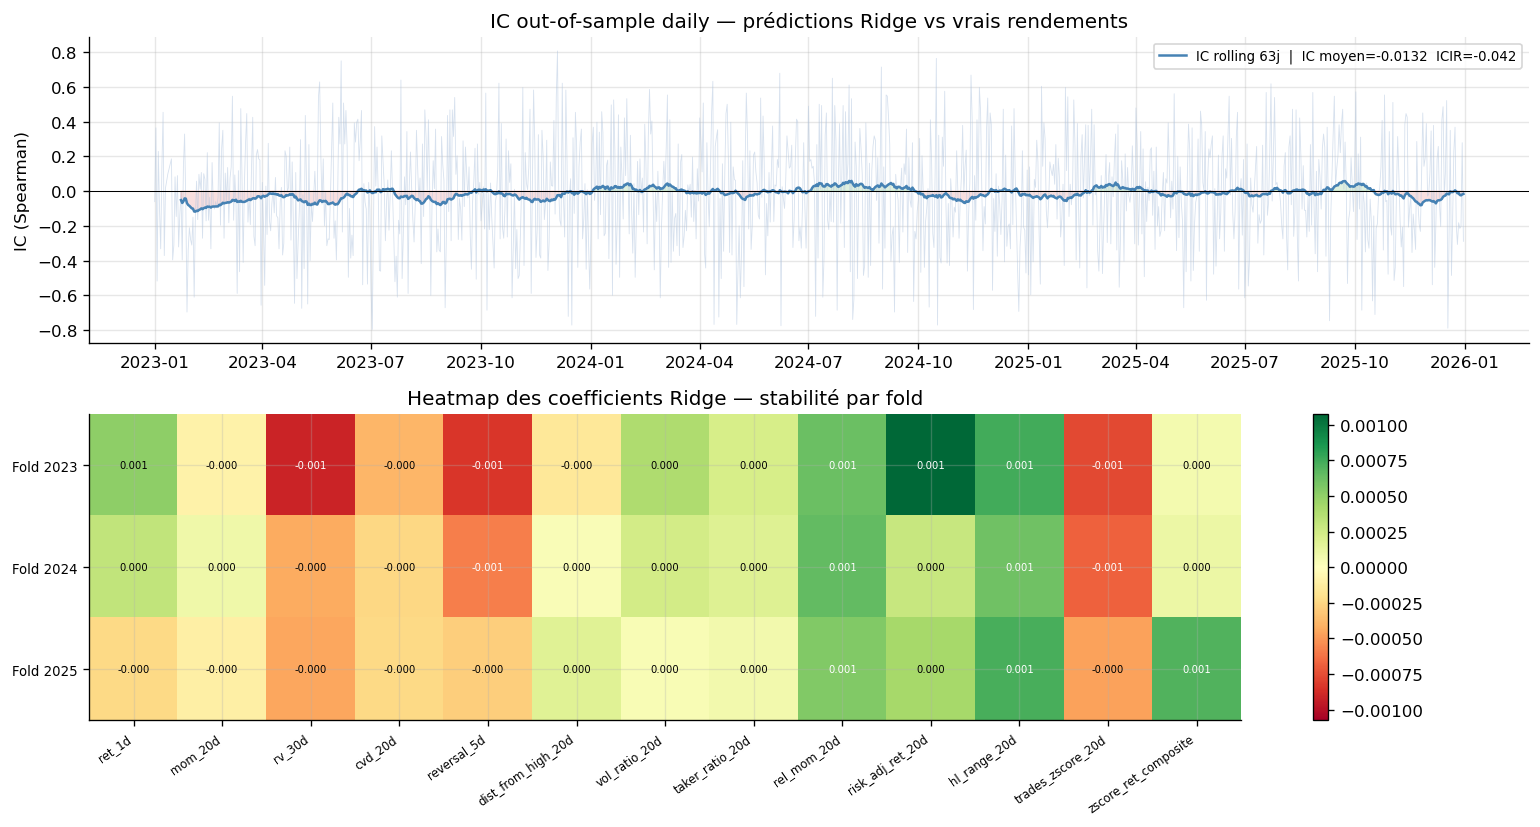


Résumé IC out-of-sample :
  IC moyen  : -0.0132
  ICIR      : -0.042
  % IC > 0  : 48.8%


In [10]:
# ── IC journalier out-of-sample ───────────────────────────────────────────────
# À chaque date, IC = corrélation de rang entre prédiction et vrai rendement
daily_ic = (
    pd.concat([all_preds.rename('pred'), all_true.rename('true')], axis=1)
    .groupby(level='date')
    .apply(lambda g: g['pred'].corr(g['true'], method='spearman'))
)

icir = daily_ic.mean() / daily_ic.std()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

# IC daily + rolling 63j
ax = axes[0]
roll_ic = daily_ic.rolling(63, min_periods=20).mean()
ax.plot(daily_ic.index, daily_ic.values, color='lightsteelblue', lw=0.5, alpha=0.5)
ax.plot(roll_ic.index,  roll_ic.values,  color='steelblue',      lw=1.5,
        label=f'IC rolling 63j  |  IC moyen={daily_ic.mean():+.4f}  ICIR={icir:+.3f}')
ax.axhline(0, color='k', lw=0.6)
ax.fill_between(roll_ic.index, 0, roll_ic.values,
                where=roll_ic.values >= 0, color='tab:green', alpha=0.15)
ax.fill_between(roll_ic.index, 0, roll_ic.values,
                where=roll_ic.values < 0,  color='tab:red',   alpha=0.15)
ax.set_ylabel('IC (Spearman)')
ax.set_title('IC out-of-sample daily — prédictions Ridge vs vrais rendements')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

# Coefficients Ridge — stabilité entre folds
ax = axes[1]
im = ax.imshow(coef_df.values, cmap='RdYlGn', aspect='auto',
               vmin=-coef_df.abs().max().max(), vmax=coef_df.abs().max().max())
ax.set_xticks(range(len(FEATURE_IDS)))
ax.set_xticklabels(FEATURE_IDS, rotation=35, ha='right', fontsize=7)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels([f'Fold {y}' for y in coef_df.index], fontsize=8)
for i in range(len(coef_df)):
    for j in range(len(FEATURE_IDS)):
        v = coef_df.values[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=6,
                color='black' if abs(v) < 0.5 * coef_df.abs().max().max() else 'white')
plt.colorbar(im, ax=ax)
ax.set_title('Heatmap des coefficients Ridge — stabilité par fold')

plt.tight_layout()
plt.show()

print(f'\nRésumé IC out-of-sample :')
print(f'  IC moyen  : {daily_ic.mean():+.4f}')
print(f'  ICIR      : {icir:+.3f}')
print(f'  % IC > 0  : {(daily_ic > 0).mean()*100:.1f}%')